# Course project

This notebook includes the code for the course project in the DTU course [Integrated Energy Grids](https://kurser.dtu.dk/course/2024-2025/46770?menulanguage=en)  and is modelling and analyzing the german energy system. 
 
The report is provided along this notebook, further explaining the results. 

### Imports

In [1]:
import pandas as pd
import pypsa
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import os
import sys

# Set path to the directory containing base.py
module_path = os.path.abspath(".")

if module_path not in sys.path:
    sys.path.append(module_path)

import base  # now you can use base.build_network()

from visualization import *

## A. Optimal capacities for selected country 
Choose a different country/region/city/system and calculate the optimal capacities for renewable and non-renewable generators. You can add as many technologies as you want. Remember to provide a reference for the cost assumptions. Plot the dispatch time series for a week in summer and winter. Plot the annual electricity mix. Use the duration curves or the capacity factor to investigate the contribution of different technologies.

In [3]:
network = base.build_network(solve=False)

/Users/jonaswiendl/Documents/46770_IEG/46770_IEG/base.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_daily["Inflow [MW]"] = df_daily["Inflow [GWh]"] * 1000 / 24  # MW average per hour


In [4]:
network.optimize(solver_name="highs")

Index(['DEU_elec'], dtype='object', name='Bus')


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 28.21it/s]
INFO:linopy.io: Writing time: 0.55s


Running HiGHS 1.9.0 (git hash: n/a): Copyright (c) 2024 HiGHS under MIT licence terms
Coefficient ranges:
  Matrix [1e-03, 1e+00]
  Cost   [1e-02, 4e+05]
  Bound  [0e+00, 0e+00]
  RHS    [6e+03, 8e+04]
Presolving model
109632 rows, 65840 cols, 267576 nonzeros  0s
100872 rows, 57080 cols, 298368 nonzeros  0s
Presolve : Reductions: rows 100872(-48061); columns 57080(-13008); elements 298368(-12757)
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0    -7.1558415104e+08 Ph1: 100872(7.07007e+07); Du: 57072(2.12048e+06) 0s
      89380     3.1888247393e+10 Pr: 0(0) 2s
Solving the original LP from the solution after postsolve
Model name          : linopy-problem-rhy_h2q1
Model status        : Optimal
Simplex   iterations: 89380
Objective value     :  3.1888247393e+10
Relative P-D gap    :  1.0646808288e-14
HiGHS run time      :          2.11


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 70088 primals, 148933 duals
Objective: 3.19e+10
Solver model: available
Solver message: optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


Writing the solution to /private/var/folders/v4/lzkm2zzd3gb0q8rqggx5drch0000gn/T/linopy-solve-npo7ggat.sol


('ok', 'optimal')

<Axes: xlabel='snapshot', ylabel='CF'>

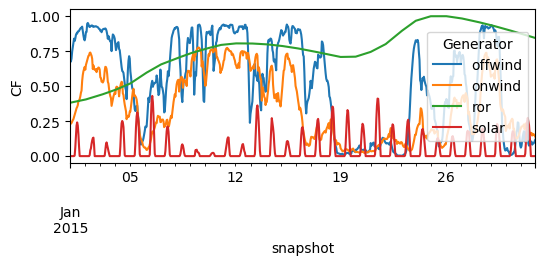

In [5]:
network.generators_t.p_max_pu.loc["2015-01"].plot(figsize=(6, 2), ylabel="CF")

In [6]:
print_summary(network)
# Plot winter week
# plot_dispatch_week(network, "2015-01-15", "2015-01-21", "Winter Dispatch")
# Plot summer week
# plot_dispatch_week(network,"2015-07-15", "2015-07-21", "Summer Dispatch")
# plot_generation_bar(network)
# plot_generation_pie(network)
# plot_duration_curves(network)
# plot_capacity_factors(network)

System Cost: 31.89 billion euros

Optimal Generator Capacities (GW):
Generator
coal           14.898778
lignite        21.000000
biomass CHP    10.000000
OCGT           31.000000
ror            -0.000000
onwind         -0.000000
offwind         2.685846
solar          -0.000000
Name: p_nom_opt, dtype: float64

Optimal Annual Energy Generation (GWh):
Generator
coal           111.236920
lignite        182.258414
biomass CHP     87.600000
OCGT           115.708797
ror              0.000000
onwind           0.000000
offwind          8.460432
solar            0.000000
dtype: float64


### Plots for the report

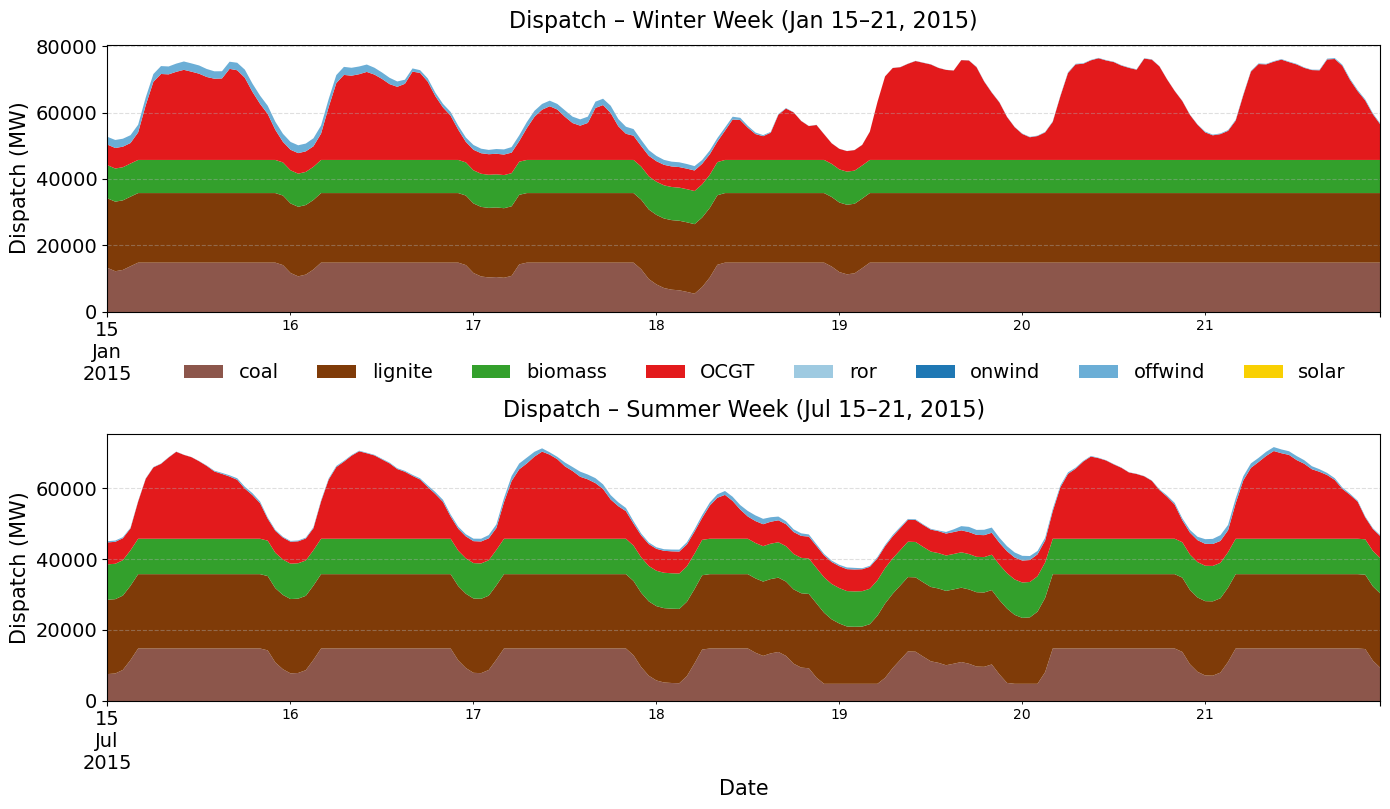

In [7]:
# Function to extract dispatch and colors
def get_dispatch_and_colors(start, end):
    dispatch = network.generators_t.p.loc[start:end]
    colors = [color_map.get(gen, "#999999") for gen in dispatch.columns]
    return dispatch, colors


# Extract data
winter_dispatch, winter_colors = get_dispatch_and_colors("2015-01-15", "2015-01-21")
summer_dispatch, summer_colors = get_dispatch_and_colors("2015-07-15", "2015-07-21")

# Create 2x1 subplot layout
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=False)

# Plot winter week
winter_dispatch.plot.area(ax=ax1, linewidth=0, color=winter_colors, legend=False)
ax1.set_title("Dispatch – Winter Week (Jan 15–21, 2015)", fontsize=16, pad=12)
ax1.set_ylabel("Dispatch (MW)", fontsize=15)
ax1.set_xlabel("", fontsize=14)
ax1.tick_params(labelsize=14)
ax1.grid(True, axis="y", linestyle="--", alpha=0.4)

# Plot summer week
summer_dispatch.plot.area(ax=ax2, linewidth=0, color=summer_colors, legend=False)
ax2.set_title("Dispatch – Summer Week (Jul 15–21, 2015)", fontsize=16, pad=12)
ax2.set_ylabel("Dispatch (MW)", fontsize=15)
ax2.set_xlabel("Date", fontsize=15)
ax2.tick_params(labelsize=14)
ax2.grid(True, axis="y", linestyle="--", alpha=0.4)

ax1.tick_params(axis='x', labelsize=14)  # for the first subplot
ax2.tick_params(axis='x', labelsize=14)  # for the second subplot


handles, labels = ax1.get_legend_handles_labels()
labels = ["biomass" if l == "biomass CHP" else l for l in labels]  # Rename label here

fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.55, 0.52),
           ncol=min(8, len(labels)), frameon=False, fontsize=14)

# Adjust layout to fit legend
plt.tight_layout(rect=[0, 0, 1, 0.91])
plt.show()

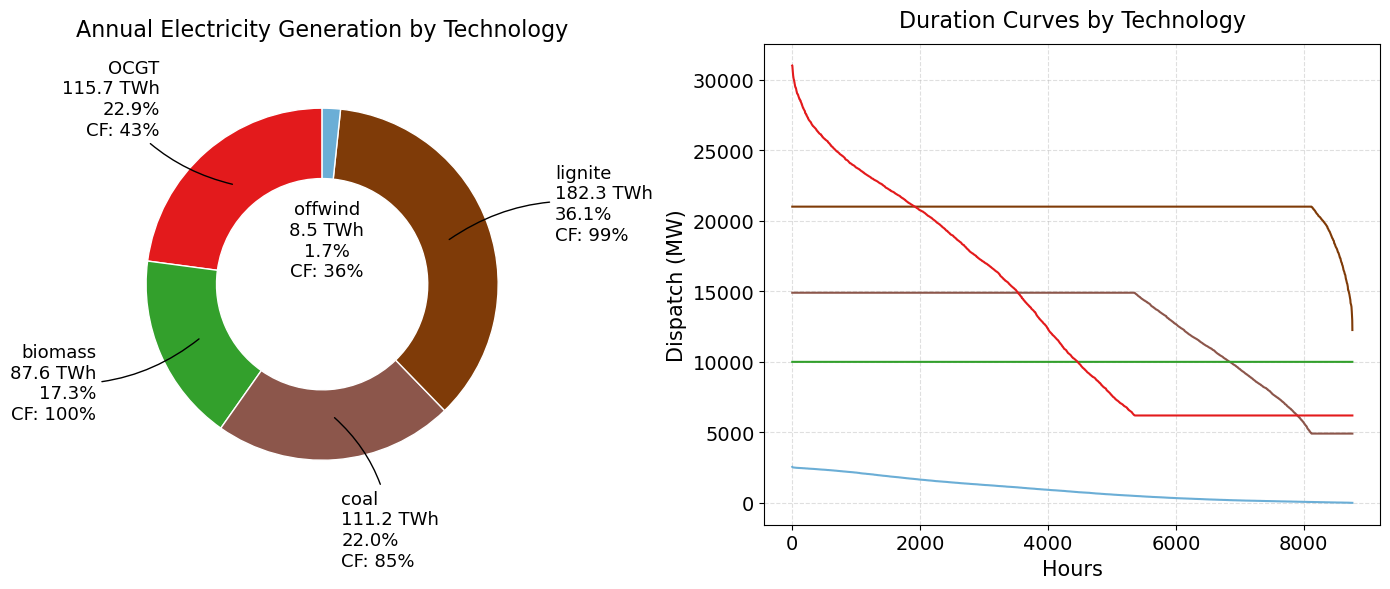

In [8]:
# Total energy generation (MWh) weighted by time
generation_by_generator = (
    network.generators_t.p
    .mul(network.snapshot_weightings.generators, axis=0)
    .sum()
)

# Group by carrier (e.g. 'solar', 'onwind', etc.)
generation_by_carrier = (
    generation_by_generator
    .groupby(network.generators.carrier)
    .sum()
    .div(1e6)  # MWh → TWh
)

# Compute capacity factors per carrier (renaming biomass CHP)
cf = (
    network.generators_t.p.sum()
    / (network.generators.p_nom_opt * 8760)
)
cf_by_carrier = (
    cf.groupby(network.generators.carrier.replace("biomass CHP", "biomass"))
    .mean()
    .sort_values(ascending=False)
)

# Prepare generation data (renaming biomass CHP)
generation_by_carrier_renamed = generation_by_carrier.rename(index={"biomass CHP": "biomass"})
labels = generation_by_carrier_renamed.index
sizes = generation_by_carrier_renamed.values
# Update color map so "biomass" reuses the "biomass CHP" color
color_map["biomass"] = color_map.get("biomass CHP", "#00aa00")  # fallback green if not defined

# Filter non-zero values
mask = sizes > 0
labels = labels[mask]
sizes = sizes[mask]
colors_filtered = [color_map.get(label, "#999999") for label in labels]

# Setup layout: donut chart (left), duration curve (right)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1, 1.4]})

# --- Donut Chart ---
wedges, texts = ax1.pie(
    sizes,
    labels=None,
    startangle=90,
    colors=colors_filtered,
    wedgeprops=dict(width=0.4, edgecolor='white')
)

for i, (wedge, label, value) in enumerate(zip(wedges, labels, sizes)):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = np.cos(np.deg2rad(angle))
    y = np.sin(np.deg2rad(angle))
    ha = 'left' if x > 0 else 'right'
    
    percent = value / sizes.sum() * 100
    cf_val = cf_by_carrier.get(label, np.nan)
    annotation = f"{label}\n{value:.1f} TWh\n{percent:.1f}%"
    if not np.isnan(cf_val):
        annotation += f"\nCF: {cf_val:.0%}"

    if label == "offwind":
        ax1.text(x * 0.5, y * 0.25, annotation, ha="center", va="center", fontsize=13)
    else:
        ax1.annotate(
            annotation,
            xy=(x * 0.75, y * 0.75),
            xytext=(x * 1.4, y * 1.4),
            ha=ha,
            va='center',
            arrowprops=dict(arrowstyle='-', connectionstyle='arc3,rad=0.2'),
            fontsize=13
        )

ax1.set_title("Annual Electricity Generation by Technology", fontsize=16, pad=20)

# --- Duration Curve ---
for tech in network.generators.carrier.unique():
    carrier = "biomass" if tech == "biomass CHP" else tech
    gen_ids = network.generators.index[network.generators.carrier == tech]
    dispatch = network.generators_t.p[gen_ids].sum(axis=1)
    if dispatch.sum() == 0:
        continue
    dispatch_sorted = dispatch.sort_values(ascending=False).reset_index(drop=True)
    ax2.plot(dispatch_sorted, label=carrier, color=color_map.get(carrier, "#999999"))

ax2.set_title("Duration Curves by Technology", fontsize=16, pad=12)
ax2.set_ylabel("Dispatch (MW)", fontsize=15)
ax2.set_xlabel("Hours", fontsize=15)
ax2.grid(True, linestyle="--", alpha=0.4)
ax2.tick_params(labelsize=14)

plt.tight_layout()
plt.show()
